# k-Nearest Neighbors for Classification

Can we predict whether a patient will test positive for diabetes from routine health measurements? k-NN answers by asking: *what did the most similar patients in our records look like?*

In this lesson we learn to:

- Explain how the **k-Nearest Neighbors** algorithm works for classification
- Control the issue of **class imbalance** at two points (`stratify` and `balanced_accuracy_score`)
- Scale features with `StandardScaler` so distances are comparable
- Connect pre-processing with model using `make_pipeline`

In [ ]:
# https://matplotlib.org/stable/
import matplotlib.pyplot as plt

# https://pandas.pydata.org/docs/
import pandas as pd

# https://seaborn.pydata.org/
import seaborn as sns

# https://scikit-learn.org/stable/modules/generated/sklearn.datasets.fetch_openml.html
from sklearn.datasets import fetch_openml

# https://scikit-learn.org/stable/modules/generated/sklearn.neighbors.KNeighborsClassifier.html
from sklearn.neighbors import KNeighborsClassifier

# https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.train_test_split.html
from sklearn.model_selection import train_test_split

# https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.StandardScaler.html
from sklearn.preprocessing import StandardScaler

# https://scikit-learn.org/stable/modules/generated/sklearn.metrics.accuracy_score.html
from sklearn.metrics import balanced_accuracy_score

# https://scikit-learn.org/stable/modules/generated/sklearn.pipeline.make_pipeline.html
from sklearn.pipeline import make_pipeline

## 1. How k-NN classification works

A **k-NN classifier** finds the $k$ training points closest to a new sample and assigns the **majority class** among those neighbors.

![Application of a k-NN classifier with k = 3 neighbors](https://upload.wikimedia.org/wikipedia/commons/7/78/KNN_decision_surface_animation.gif)

- **Left:** for the test point "?", the algorithm finds the 3 closest training points and takes the majority vote.
- **Right:** repeating the prediction across the feature space traces out the decision boundary.

## 2. Load the dataset

We use the **Pima Indians Diabetes** dataset from OpenML (id 37):

- **Features:** eight numeric health measurements (pregnancies, glucose, blood pressure, …).
- **Target:** `class` — `tested_positive` or `tested_negative` for diabetes onset.

In [18]:
diabetes = fetch_openml(
    data_id=37,  # Pima Indians Diabetes on OpenML
    as_frame=True,
    parser="pandas",
)

X = diabetes.data
y = diabetes.target

X.head()

,preg,plas,pres,skin,insu,mass,pedi,age
0,6,148,72,35,0,33.6,0.627,50
1,1,85,66,29,0,26.6,0.351,31
2,8,183,64,0,0,23.3,0.672,32
3,1,89,66,23,94,28.1,0.167,21
4,0,137,40,35,168,43.1,2.288,33


In [19]:
y.head()

0    tested_positive
1    tested_negative
2    tested_positive
3    tested_negative
4    tested_positive
Name: class, dtype: category
Categories (2, str): ['tested_negative', 'tested_positive']

## 3. Class imbalance

Real classification problems are often **imbalanced**: one class appears much more often than the other.

- If ~65% of patients test negative, a model that **always** predicts `tested_negative` scores ~65% accuracy — without learning anything useful.
- **Accuracy** (fraction of correct predictions) hides poor performance on the minority class.
- Under imbalance, also inspect **balanced accuracy** or per-class metrics (covered in the classification-metrics lesson).

In [20]:
class_counts = y.value_counts()
class_proportions = y.value_counts(normalize=True)

print("Counts:")
print(class_counts)
print("\nProportions:")
print(class_proportions.round(3))

Counts:
class
tested_negative    500
tested_positive    268
Name: count, dtype: int64

Proportions:
class
tested_negative    0.651
tested_positive    0.349
Name: proportion, dtype: float64


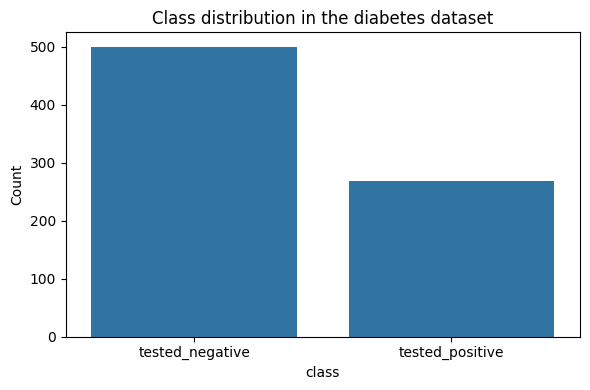

In [21]:
fig, ax = plt.subplots(figsize=(6, 4))

sns.countplot(
    data=pd.DataFrame({"class": y}),
    x="class",  # one bar per class label
    order=class_counts.index,
    ax=ax,
    color=sns.color_palette()[0]
)
ax.set_title("Class distribution in the diabetes dataset")
ax.set_ylabel("Count")

fig.tight_layout()
plt.show()

In [22]:
# Naive baseline: always predict the majority class
majority_class = class_counts.idxmax()
naive_predictions = pd.Series(majority_class, index=y.index)

naive_accuracy = balanced_accuracy_score(y, naive_predictions)
print(f"Always predicting '{majority_class}': accuracy = {naive_accuracy:.3f}")

Always predicting 'tested_negative': accuracy = 0.500


## 4. Stratified train-test split

When classes are imbalanced, a random split can put a **different** class mix in train vs test — especially with small datasets.

**`stratify=y`** asks `train_test_split` to preserve the overall class proportions in both subsets.

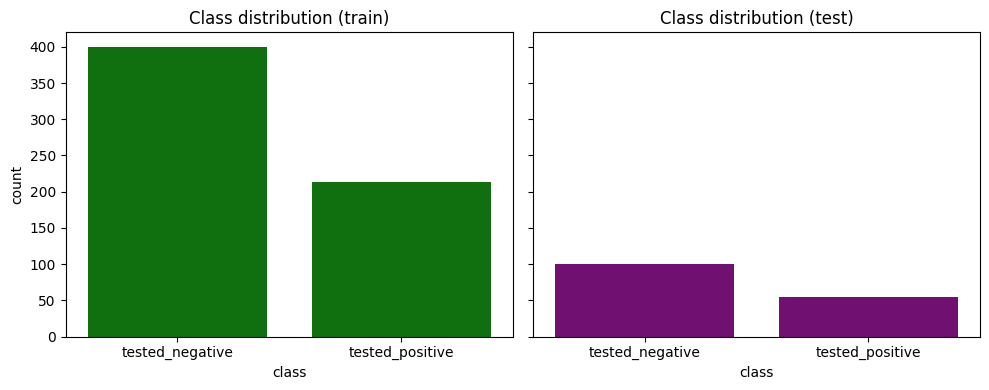

In [23]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,  # hold out 20% for evaluation
    random_state=42,  # reproducible split
    stratify=y,  # keep class proportions in both splits
)

fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharey=True)

sns.countplot(
    x=y_train,
    ax=axes[0],
    order=y.value_counts().index,
    color='green'
)
axes[0].set_title("Class distribution (train)")
axes[0].set_xlabel("class")
axes[0].set_ylabel("count")

sns.countplot(
    x=y_test,
    ax=axes[1],
    order=y.value_counts().index,
    color='purple'
)
axes[1].set_title("Class distribution (test)")
axes[1].set_xlabel("class")
axes[1].set_ylabel("")

fig.tight_layout()
plt.show()

Notice the proportion of negatives to positives is the same across the two splits.

## 5. Fit a k-NN classifier

We now train the classifier. But k-NN compares patients by **distance** — so a feature on a large range (like `insu`, serum insulin, which reaches into the hundreds) would dominate a small-range feature (like `pedi`, the diabetes pedigree function, which sits below ~2.5).

We fix this by **scaling** the features first.

### What `StandardScaler` does

[`StandardScaler`](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.StandardScaler.html) shifts each column to a **mean of 0** and a **standard deviation of 1**, expressing every value in "standard units" (z-scores):

$$z = \frac{x - \mu}{s}$$

- $\mu$ and $s$ are the mean and standard deviation learned from the **training** data only.
- Every feature ends up on a comparable footing, so no single column dominates the distance.

For the full treatment of linear scaling, see [Numerical Scaling](numerical_scaling.ipynb).

In [24]:
# Learn the scaling on train only, then transform train
scaler_demo = StandardScaler()
X_train_scaled = pd.DataFrame(
    scaler_demo.fit_transform(X_train),
    columns=X_train.columns,  # keep readable feature names
    index=X_train.index,
)

# Each raw column has a different mean/std; after scaling they all sit at ~0 / ~1
stats = pd.DataFrame(
    {
        "mean (raw)": X_train.mean(),
        "std (raw)": X_train.std(),
        "mean (scaled)": X_train_scaled.mean(),
        "std (scaled)": X_train_scaled.std(),
    }
)
stats.round(2)

,mean (raw),std (raw),mean (scaled),std (scaled)
preg,3.82,3.31,-0.0,1.0
plas,120.91,31.56,0.0,1.0
pres,69.44,18.40,-0.0,1.0
skin,20.78,15.86,-0.0,1.0
insu,78.67,107.74,-0.0,1.0
mass,31.97,7.86,0.0,1.0
pedi,0.48,0.33,-0.0,1.0
age,33.37,11.83,-0.0,1.0


### Does scaling help?

To see the impact, we fit the **same** `KNeighborsClassifier` twice and compare **balanced accuracy** (the average of per-class recall, which stays fair under class imbalance):

- **Before:** k-NN on the raw, unscaled features.
- **After:** k-NN on `StandardScaler`-transformed features, chained together with `make_pipeline`.

In [25]:
# BEFORE: k-NN on the raw features, with no scaling
knn_unscaled = KNeighborsClassifier(
    n_neighbors=5,  # majority vote among 5 nearest patients
)
knn_unscaled.fit(X_train, y_train)

y_pred_unscaled = knn_unscaled.predict(X_test)
bacc_unscaled = balanced_accuracy_score(y_test, y_pred_unscaled)

print(f"Balanced accuracy WITHOUT scaling: {bacc_unscaled:.3f}")

Balanced accuracy WITHOUT scaling: 0.626


In [26]:
# AFTER: scale, then classify — chained so the scaler never sees the test set during fit
pipe = make_pipeline(
    StandardScaler(),  # z-score each feature
    KNeighborsClassifier(n_neighbors=5),  # same k as the unscaled model
)
pipe.fit(X_train, y_train)

y_pred_scaled = pipe.predict(X_test)
bacc_scaled = balanced_accuracy_score(y_test, y_pred_scaled)

print(f"Balanced accuracy WITH scaling:    {bacc_scaled:.3f}")

Balanced accuracy WITH scaling:    0.659


In [27]:
# Side-by-side, against the naive majority-class baseline (also a balanced accuracy of ~0.5)
comparison = pd.Series(
    {
        "naive baseline": naive_accuracy,
        "k-NN (unscaled)": bacc_unscaled,
        "k-NN (scaled)": bacc_scaled,
    },
    name="balanced accuracy",
)
comparison.round(3)

naive baseline     0.500
k-NN (unscaled)    0.626
k-NN (scaled)      0.659
Name: balanced accuracy, dtype: float64

Scaling lifts the balanced accuracy: on raw features the large-range columns dominate the distance, so neighbors are chosen on the wrong basis. After `StandardScaler`, every feature contributes fairly and the nearest neighbors become more meaningful.

> **Note:** The pipeline applies the scaler's `fit` to the training data only, so no test information leaks into preprocessing. Full metric treatment (confusion matrix, precision, recall, ROC) lives in the classification-metrics lesson.

## Recap

- k-NN classification assigns the **majority class** among the $k$ nearest training points.
- **Imbalanced** targets make raw accuracy misleading — compare against a majority-class baseline.
- Use **`stratify=y`** in `train_test_split` so train and test reflect the same class mix.
- Wrap **`StandardScaler`** and **`KNeighborsClassifier`** in a `make_pipeline` for consistent reuse.

## References

- [Nearest Neighbors classification](https://scikit-learn.org/stable/modules/neighbors.html#classification)
- [KNeighborsClassifier API](https://scikit-learn.org/stable/modules/generated/sklearn.neighbors.KNeighborsClassifier.html)
- [train_test_split — stratify parameter](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.train_test_split.html)